In [1]:
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt

In [2]:
from pathlib import Path
DATA = Path("..") / "data"   

books  = [json.loads(l) for l in open(DATA / "book.jsonl")]
rows = []

In [3]:
for b in books:
    bid, ask = b["bids"][0][0], b["asks"][0][0]
    rows.append({"ts": b["ts"], "mid": (bid+ask)/2, "spread": ask-bid,
                 "bid_depth": sum(level[1] for level in b["bids"]),
                 "ask_depth": sum(level[1] for level in b["asks"])})
df = pd.DataFrame(rows); df["time"] = pd.to_datetime(df["ts"], unit="ms")
df = df.sort_values("ts").reset_index(drop=True)

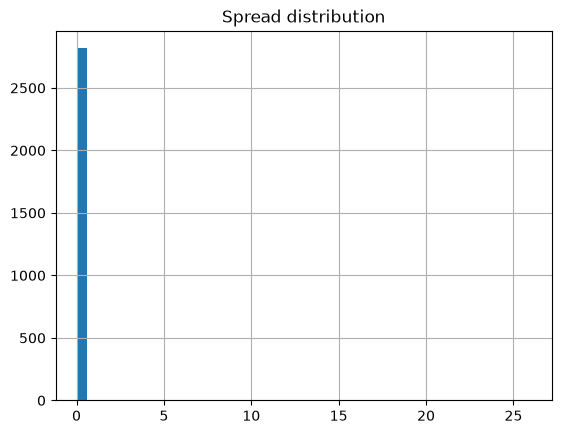

count    2835.000000
mean        0.191640
std         1.349413
min         0.100000
25%         0.100000
50%         0.100000
75%         0.100000
max        25.900000
Name: spread, dtype: float64


In [4]:
df["spread"].hist(bins=50); plt.title("Spread distribution"); plt.show()
print(df["spread"].describe())

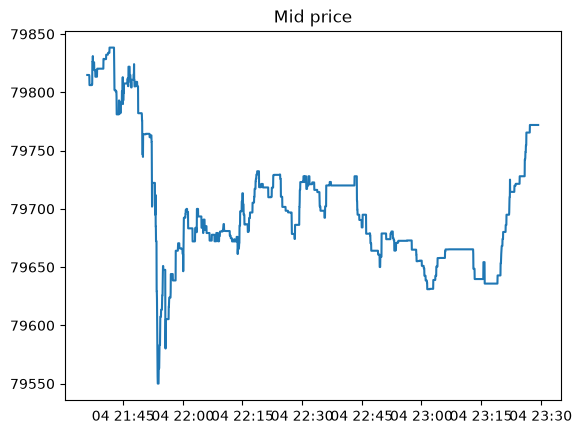

fraction of snapshots where mid changed: 0.10758377425044091


In [5]:
plt.plot(df["time"], df["mid"]); plt.title("Mid price"); plt.show()
print("fraction of snapshots where mid changed:", (df["mid"].diff() != 0).mean())


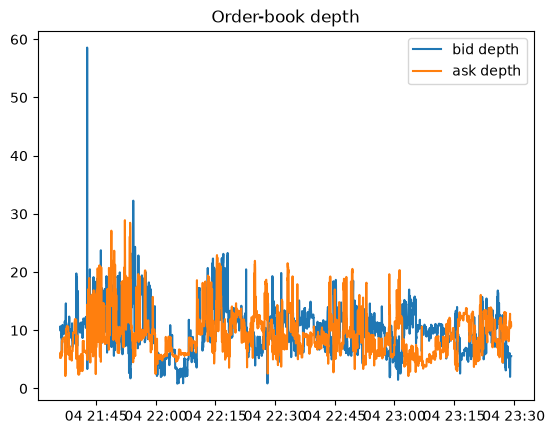

In [6]:
plt.plot(df["time"], df["bid_depth"], label="bid depth")
plt.plot(df["time"], df["ask_depth"], label="ask depth")
plt.legend(); plt.title("Order-book depth"); plt.show()

In [7]:
trades = [json.loads(l) for l in open("../data/trades.jsonl")]
td = pd.DataFrame(trades)
duration_s = (td["ts"].max() - td["ts"].min()) / 1000
print(f"trade arrival rate ~= {len(td)/duration_s:.3f} per second")
print(td["side"].value_counts())

trade arrival rate ~= 0.682 per second
side
buy     2869
sell    1803
Name: count, dtype: int64


In [8]:
'''
~ 90 min of data collected
spread = 0.100000
mid-volatility = 0.035861258083480306
arrival rate = 0.682/sec
'''

'\n~ 90 min of data collected\nspread = 0.100000\nmid-volatility = 0.035861258083480306\narrival rate = 0.682/sec\n'

final PnL:       1073.4
buy fills:       1105
sell fills:      1078
final inventory: 27.0


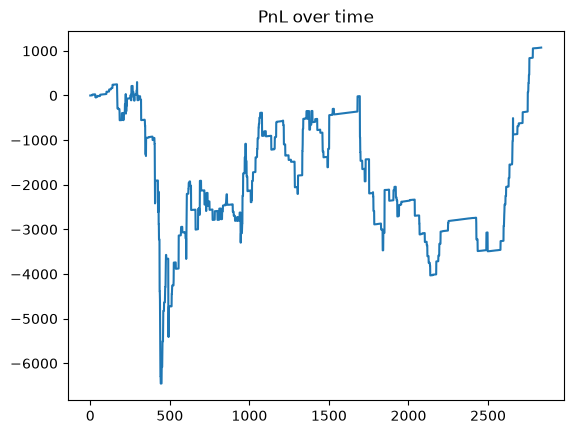

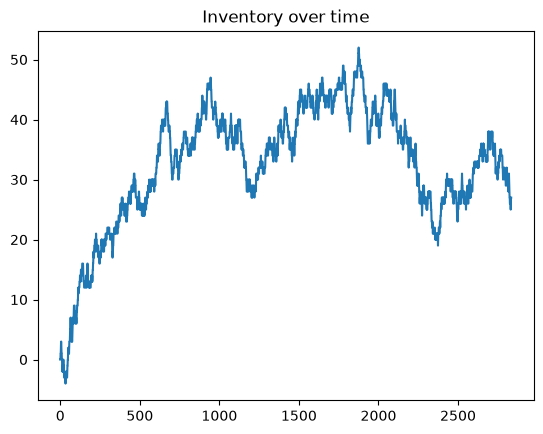

In [9]:
from simulator import MarketMakingSimulator, SimConfig, fixed_spread_strategy

mids = df.sort_values("ts")["mid"].to_numpy()          # your Step 1 price path

sim = MarketMakingSimulator(mids, SimConfig(A=1.0, kappa=1.5, dt=1.0, seed=42))
hist, final_pnl = sim.run(fixed_spread_strategy(half_spread=0.5))

print("final PnL:      ", round(final_pnl, 2))
print("buy fills:      ", int(hist["buy_fill"].sum()))
print("sell fills:     ", int(hist["sell_fill"].sum()))
print("final inventory:", hist["inventory"][-1])

plt.plot(hist["pnl"]);       plt.title("PnL over time");       plt.show()
plt.plot(hist["inventory"]); plt.title("Inventory over time"); plt.show()

          final_pnl      n_fills  max_abs_inventory  terminal_inventory  \
count    200.000000   200.000000         200.000000          200.000000   
mean     711.308750  2131.130000          45.145000           -5.410000   
std     3535.723836    35.654302          19.018478           37.282595   
min    -8580.650000  2031.000000          16.000000         -107.000000   
25%    -1523.350000  2110.000000          31.000000          -28.000000   
50%      642.225000  2129.000000          42.000000           -5.000000   
75%     2989.450000  2155.000000          55.000000           19.000000   
max    10659.400000  2240.000000         121.000000          120.000000   

       inventory_std  
count     200.000000  
mean       13.862596  
std         5.948404  
min         5.365270  
25%         9.411365  
50%        12.438620  
75%        16.231928  
max        35.884815  


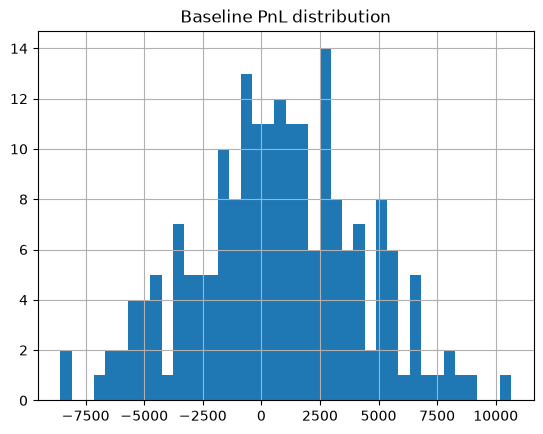

In [10]:
from evaluation import monte_carlo, summarize
from simulator import SimConfig, fixed_spread_strategy

mids = df.sort_values("ts")["mid"].to_numpy()
base = SimConfig(A=1.0, kappa=1.5, dt=1.0)

res = monte_carlo(mids, fixed_spread_strategy(half_spread=0.5), base, n_runs=200)
print(res.describe())
res["final_pnl"].hist(bins=40); plt.title("Baseline PnL distribution"); plt.show()

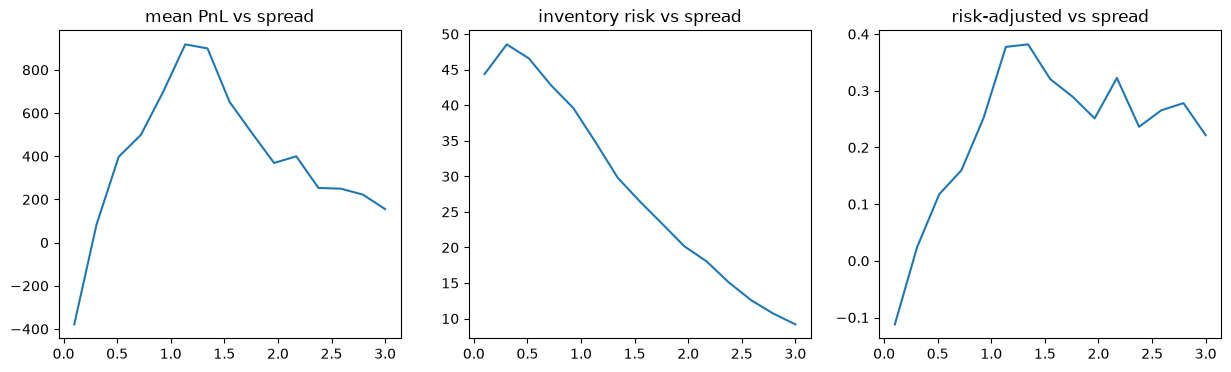

    mean_pnl   std_pnl   pnl_p05  sharpe_like  mean_max_abs_inventory  \
0   -378.872  3378.817 -5527.102       -0.112                   44.37   
1     82.400  3450.899 -5989.180        0.024                   48.55   
2    396.990  3378.848 -5498.509        0.117                   46.57   
3    498.708  3119.994 -4522.070        0.160                   42.78   
4    697.106  2760.972 -3547.446        0.252                   39.59   
5    917.800  2432.058 -3010.886        0.377                   34.79   
6    899.273  2355.553 -3020.394        0.382                   29.79   
7    650.749  2030.492 -2917.212        0.320                   26.45   
8    507.838  1752.909 -2252.736        0.290                   23.33   
9    368.676  1467.389 -2111.483        0.251                   20.16   
10   399.479  1238.635 -1427.466        0.323                   18.04   
11   252.996  1070.167 -1505.431        0.236                   15.09   
12   249.695   940.513 -1251.796        0.265      

In [11]:
import numpy as np, pandas as pd

spreads = np.linspace(0.1, 3.0, 15)
rows = []
for hs in spreads:
    s = summarize(monte_carlo(mids, fixed_spread_strategy(hs), base, n_runs=100))
    s["half_spread"] = hs
    rows.append(s)
sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(sweep["half_spread"], sweep["mean_pnl"]);   ax[0].set_title("mean PnL vs spread")
ax[1].plot(sweep["half_spread"], sweep["mean_max_abs_inventory"]); ax[1].set_title("inventory risk vs spread")
ax[2].plot(sweep["half_spread"], sweep["sharpe_like"]); ax[2].set_title("risk-adjusted vs spread")
plt.show()
print(sweep.round(3))

In [12]:
best_hs = sweep.loc[sweep["sharpe_like"].idxmax(), "half_spread"]
benchmark = summarize(monte_carlo(mids, fixed_spread_strategy(best_hs), base, n_runs=500))
benchmark["half_spread"] = best_hs
print("BASELINE BENCHMARK:", {k: round(v, 3) for k, v in benchmark.items()})

BASELINE BENCHMARK: {'mean_pnl': np.float64(862.894), 'std_pnl': np.float64(2278.662), 'pnl_p05': np.float64(-3061.335), 'sharpe_like': np.float64(0.379), 'mean_max_abs_inventory': np.float64(31.36), 'mean_n_fills': np.float64(708.302), 'half_spread': np.float64(1.343)}
